In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Task 1(a): Load and visualize one random image from each class
What this asks

From the train folder:

read all class subfolders
pick one random image from each class
show them in a 2-row grid
then write a short observation

In [23]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report

Find dataset root automatically

In [4]:
search_root = "/content/drive/MyDrive"
dataset_root = None

for root, dirs, files in os.walk(search_root):
    if "train" in dirs and "test" in dirs:
        dataset_root = root
        break

if dataset_root is None:
    raise FileNotFoundError("Could not find a folder containing both 'train' and 'test'.")

print("Dataset root found:", dataset_root)

train_dir = os.path.join(dataset_root, "train")
test_dir = os.path.join(dataset_root, "test")

print("Train path:", train_dir)
print("Test path:", test_dir)
print("Train exists:", os.path.exists(train_dir))
print("Test exists:", os.path.exists(test_dir))

Dataset root found: /content/drive/MyDrive/Week-5/FruitinAmazon
Train path: /content/drive/MyDrive/Week-5/FruitinAmazon/train
Test path: /content/drive/MyDrive/Week-5/FruitinAmazon/test
Train exists: True
Test exists: True


Task 1(a): visualize one random image from each class

Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


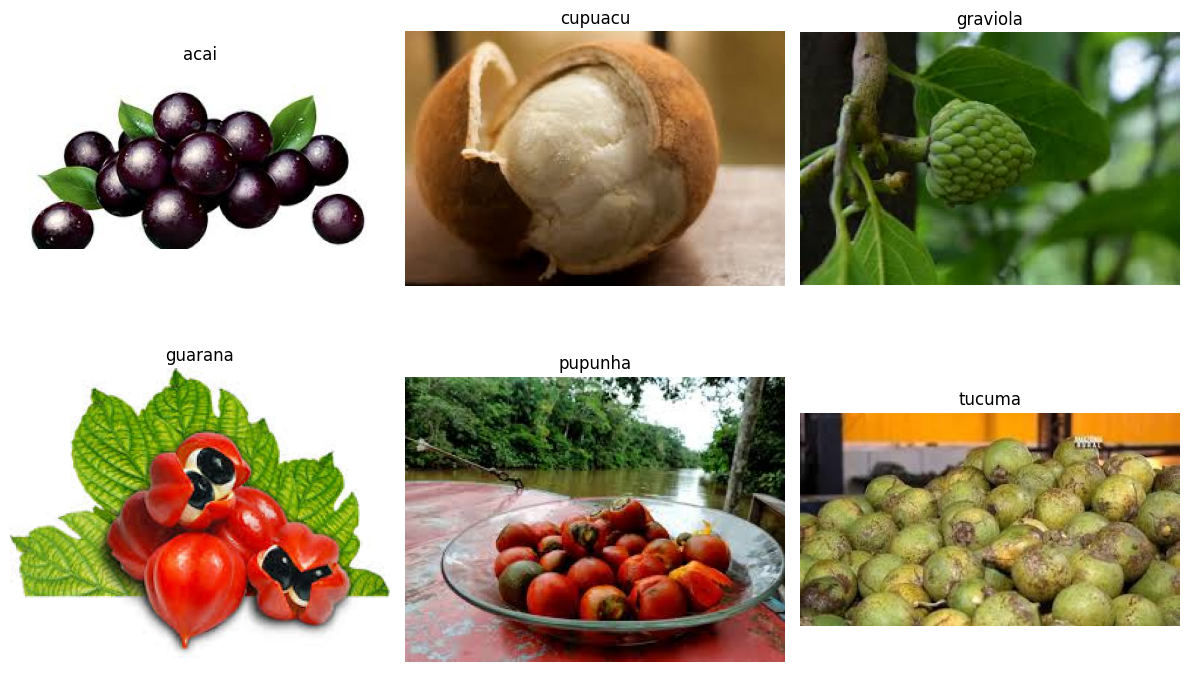

In [5]:
class_names = sorted(
    [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
)

print("Classes:", class_names)

sample_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ]
    image_name = random.choice(image_files)
    sample_images.append((class_name, os.path.join(class_path, image_name)))

plt.figure(figsize=(12, 8))

for i, (class_name, image_path) in enumerate(sample_images, 1):
    plt.subplot(2, (len(sample_images) + 1) // 2, i)
    plt.imshow(Image.open(image_path))
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

Task 1(b): check and remove corrupted images

In [6]:
corrupted_images = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    for image_name in os.listdir(class_path):
        if not image_name.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
            continue

        image_path = os.path.join(class_path, image_name)

        try:
            with Image.open(image_path) as img:
                img.verify()
        except (IOError, SyntaxError, OSError):
            corrupted_images.append(image_path)
            os.remove(image_path)
            print(f"Removed corrupted image: {image_path}")

if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")
else:
    print("Total corrupted images removed:", len(corrupted_images))

No Corrupted Images Found.


Task 2: Load and preprocess image data in Keras

This task wants you to:</br>

load images from directory</br>
create training and validation datasets</br>
resize images</br>
batch them</br>
normalize pixel values to [0, 1] using Rescaling(1./255)

In [10]:
img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset="training",
    seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset="validation",
    seed=123
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


Task 3: Build the CNN model

For Task 3, you need to create the CNN with this structure:

Conv2D: 32 filters, 3x3, padding=same, stride=1
ReLU
MaxPooling2D: 2x2, stride=2
Conv2D: 32 filters, 3x3, padding=same, stride=1
ReLU
MaxPooling2D: 2x2, stride=2
Flatten
Dense hidden layers with 64 and 128 neurons
Output layer with num_classes neurons

In [13]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), strides=1, padding="same", activation="relu",
                  input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    layers.Conv2D(32, (3, 3), strides=1, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

In [14]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

Task 4: Compile and train the model

In [15]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Create callbacks

In [16]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

Train the model

In [17]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stopping]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.1910 - loss: 1.9799
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 389ms/step - accuracy: 0.1528 - loss: 2.0017 - val_accuracy: 0.0000e+00 - val_loss: 1.7834
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.2417 - loss: 1.7592
Epoch 2: val_accuracy did not improve from 0.00000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 304ms/step - accuracy: 0.2917 - loss: 1.7495 - val_accuracy: 0.0000e+00 - val_loss: 1.8422
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.2295 - loss: 1.6908
Epoch 3: val_accuracy did not improve from 0.00000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 469ms/step - accuracy: 0.2778 - loss: 1.6175 - val_accuracy: 0.0000e+00 - val_loss: 1.7778
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.3719 - loss: 1.4201
Epoch 4: val_accuracy improved from 0.00000 to 0.38889, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 480ms/step - accuracy: 0.4167 - loss: 1.3949 - val_accuracy: 0.3889 - val_loss: 1.4229
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.7552 - loss: 1.0903
Epoch 5: val_accuracy improved from 0.38889 to 0.66667, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 286ms/step - accuracy: 0.7083 - loss: 1.0748 - val_accuracy: 0.6667 - val_loss: 0.9692
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.8038 - loss: 0.7453
Epoch 6: val_accuracy did not improve from 0.66667
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 269ms/step - accuracy: 0.8472 - loss: 0.6560 - val_accuracy: 0.5556 - val_loss: 1.3176
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.8823 - loss: 0.3793
Epoch 7: val_accuracy did not improve from 0.66667
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 270ms/step - accuracy: 0.8333 - loss: 0.4491 - val_accuracy: 0.6667 - val_loss: 0.7618
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.9594 - loss: 0.2533
Epoch 8: val_accuracy improved from 0.66667 to 0.88889, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 330ms/step - accuracy: 0.9583 - loss: 0.2656 - val_accuracy: 0.8889 - val_loss: 0.3773
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.9712 - loss: 0.1563
Epoch 9: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 311ms/step - accuracy: 0.9861 - loss: 0.1498 - val_accuracy: 0.8333 - val_loss: 0.4130
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.9740 - loss: 0.0882
Epoch 10: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 296ms/step - accuracy: 0.9583 - loss: 0.1169 - val_accuracy: 0.8333 - val_loss: 0.3757
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.9899 - loss: 0.0444
Epoch 11: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 453ms/step - accuracy: 0.9861 - loss: 0.0504 - val_accuracy: 0.7778 - val_loss: 0.8443
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 1.0000 - loss: 

Task 5: Evaluate the model

Now evaluate on the test set:

In [19]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.7333 - loss: 0.9359
Test Loss: 0.9359
Test Accuracy: 0.7333


Next: Task 6 - Save and load the model

In [20]:
model.save("fruit_classifier.h5")

In [21]:
loaded_model = tf.keras.models.load_model("fruit_classifier.h5")

In [22]:
loaded_test_loss, loaded_test_accuracy = loaded_model.evaluate(test_ds)

print(f"Loaded Model Test Loss: {loaded_test_loss:.4f}")
print(f"Loaded Model Test Accuracy: {loaded_test_accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.7333 - loss: 0.9359
Loaded Model Test Loss: 0.9359
Loaded Model Test Accuracy: 0.7333


Task 7: Predictions and Classification Report:</br>
make predictions on the test set</br>
convert predicted probabilities to labels using np.argmax()</br>
show the classification report</br>

In [24]:
y_true = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

y_pred_probs = loaded_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Actual labels:", y_true)
print("Predicted labels:", y_pred)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 258ms/step
Actual labels: [0 0 0 0 0 1 1 1 1 1 2 2 2 2 2 3 3 3 3 3 4 4 4 4 4 5 5 5 5 5]
Predicted labels: [0 0 0 0 0 1 1 1 5 1 2 2 2 2 2 4 1 3 4 0 4 4 4 4 4 5 1 0 5 1]

Classification Report:

              precision    recall  f1-score   support

        acai       0.71      1.00      0.83         5
     cupuacu       0.57      0.80      0.67         5
    graviola       1.00      1.00      1.00         5
     guarana       1.00      0.20      0.33         5
     pupunha       0.71      1.00      0.83         5
      tucuma       0.67      0.40      0.50         5

    accuracy                           0.73        30
   macro avg       0.78      0.73      0.69        30
weighted avg       0.78      0.73      0.69        30



plot training and validation accuracy/loss

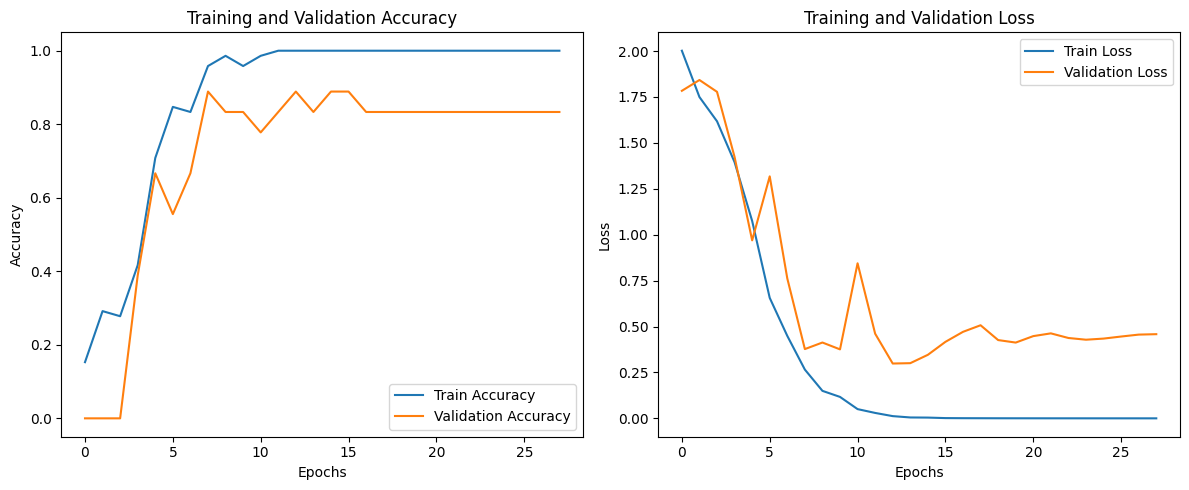

In [25]:
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# Conclusion:
# The CNN model was successfully built, trained, evaluated, saved, and reloaded.
# The model achieved good training performance and a test accuracy of about 73.33%.
# The training and validation curves show mild overfitting, but EarlyStopping helped
# restore the best model. The classification report shows that some classes were
# predicted better than others, while a few classes remain more challenging.